# Evaluation Graphs of Models

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('eval.csv')

yt_red = '#FF0000'
yt_black = '#282828'
yt_gray = '#F9F9F9'
yt_dark_gray = '#606060'

df_melted = df.melt(
    id_vars="Model Name", 
    value_vars=["Macro Avg Precision", "Macro Avg Recall", "Macro Avg F1"],
    var_name="Metric", 
    value_name="Score"
)



### How all the models did by complexity

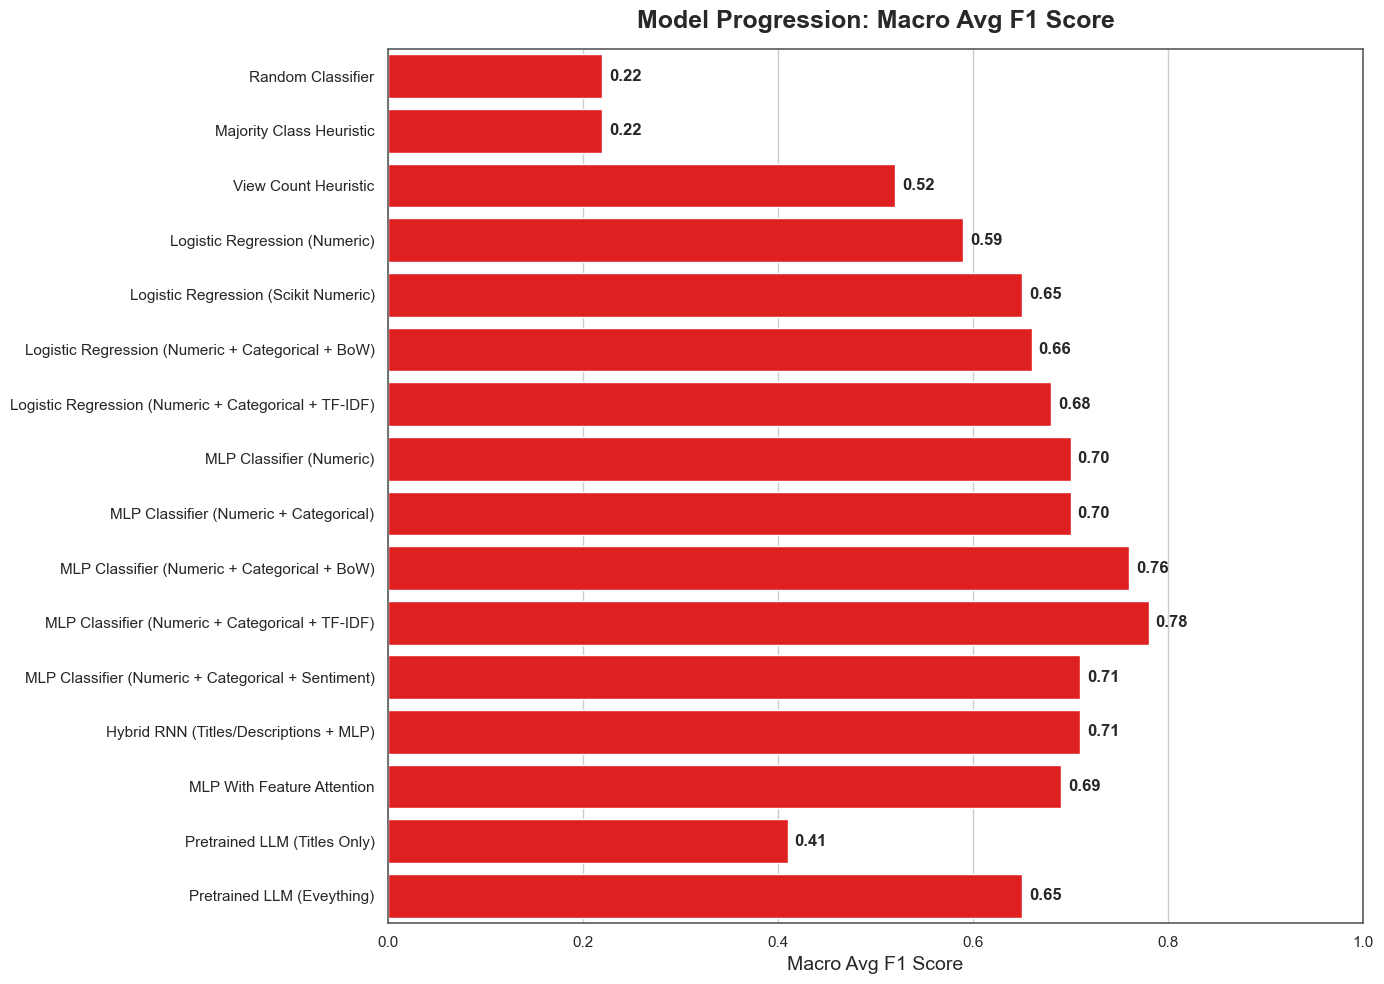

In [10]:
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": yt_dark_gray})

ax1 = sns.barplot(x="Macro Avg F1", y="Model Name", data=df, color=yt_red)

plt.title("Model Progression: Macro Avg F1 Score", fontsize=18, fontweight='bold', color=yt_black, pad=15)
plt.xlabel("Macro Avg F1 Score", fontsize=14, color=yt_black)
plt.ylabel("", fontsize=14)
plt.xlim(0, 1.0)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.2f}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', 
                 xytext=(5, 0), textcoords='offset points',
                 fontsize=12, color=yt_black, fontweight='bold')
                 
plt.tight_layout()
plt.show()

### Model Ranking

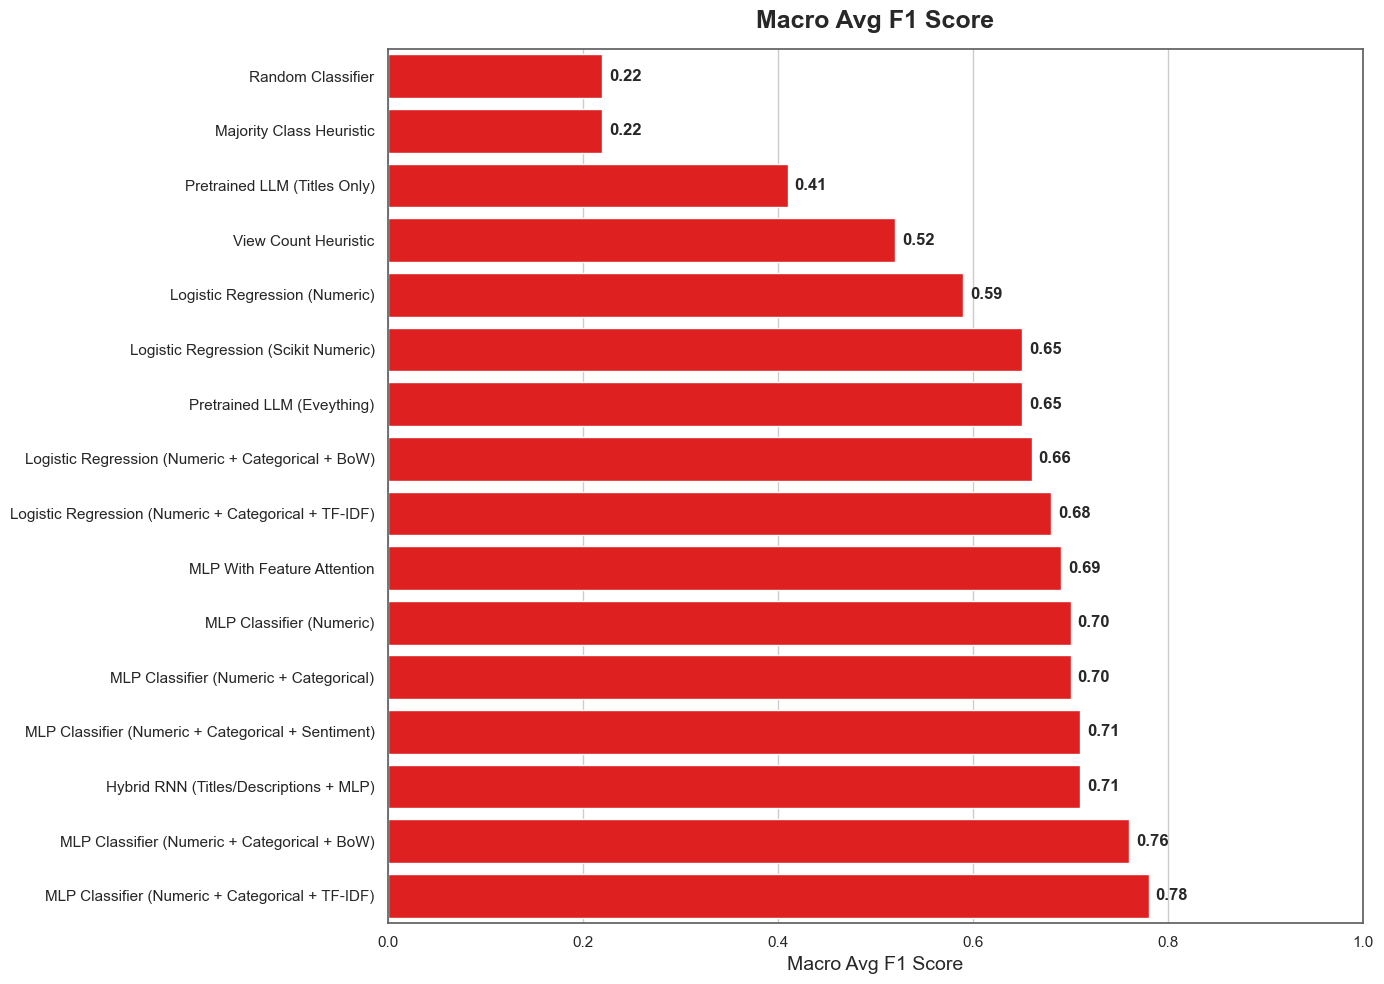

In [11]:
# 1. Sort the dataframe from low to high (ascending=True)
df_sorted = df.sort_values(by="Macro Avg F1", ascending=True)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": yt_dark_gray})

# 2. Update data=df to data=df_sorted
ax1 = sns.barplot(x="Macro Avg F1", y="Model Name", data=df_sorted, color=yt_red)

plt.title("Macro Avg F1 Score", fontsize=18, fontweight='bold', color=yt_black, pad=15)
# plt.title("Accuracy", fontsize=18, fontweight='bold', color=yt_black, pad=15)
plt.xlabel("Macro Avg F1 Score", fontsize=14, color=yt_black)
plt.ylabel("", fontsize=14)
plt.xlim(0, 1.0)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.2f}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', 
                 xytext=(5, 0), textcoords='offset points',
                 fontsize=12, color=yt_black, fontweight='bold')
                 
plt.tight_layout()
plt.show()

#### Chart to show the class imbalance in our dataset

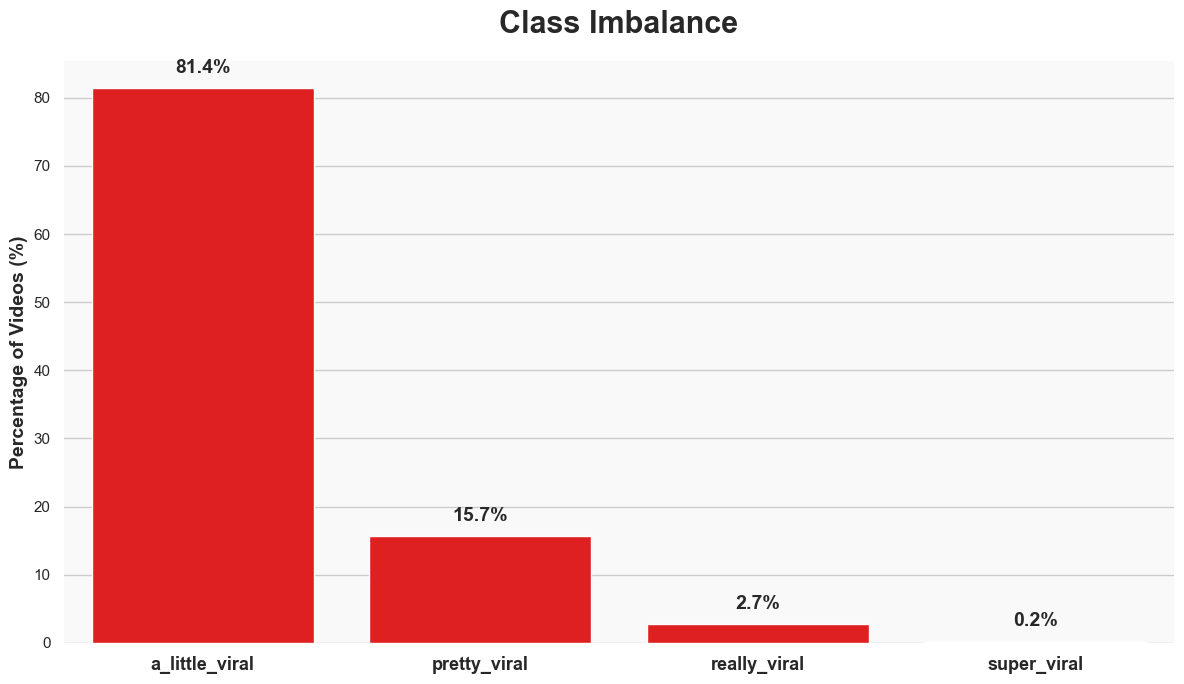

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Virality Tier": ["a_little_viral", "pretty_viral", "really_viral", "super_viral"],
    "Support (Number of Videos)": [73784, 14234, 2486, 170]
}
df_support = pd.DataFrame(data)

total_videos = df_support["Support (Number of Videos)"].sum()
df_support["Percentage"] = (df_support["Support (Number of Videos)"] / total_videos) * 100

yt_red = '#FF0000'
yt_black = '#282828'
yt_gray = '#F9F9F9'
yt_dark_gray = '#606060'

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": yt_gray, "figure.facecolor": "white", "axes.edgecolor": yt_dark_gray})

ax = sns.barplot(
    x="Virality Tier", 
    y="Percentage", 
    data=df_support, 
    color=yt_red
)

plt.title("Class Imbalance", fontsize=22, fontweight='bold', color=yt_black, pad=20)
plt.xlabel("", fontsize=14) 
plt.ylabel("Percentage of Videos (%)", fontsize=14, fontweight='bold', color=yt_black)

plt.xticks(fontsize=13, fontweight='bold', color=yt_black)
plt.yticks(fontsize=11, color=yt_black)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', 
                 xytext=(0, 8), textcoords='offset points',
                 fontsize=14, color=yt_black, fontweight='bold')
                 
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

#### This is a graph to demonstrate why we used F1 over Accuracy

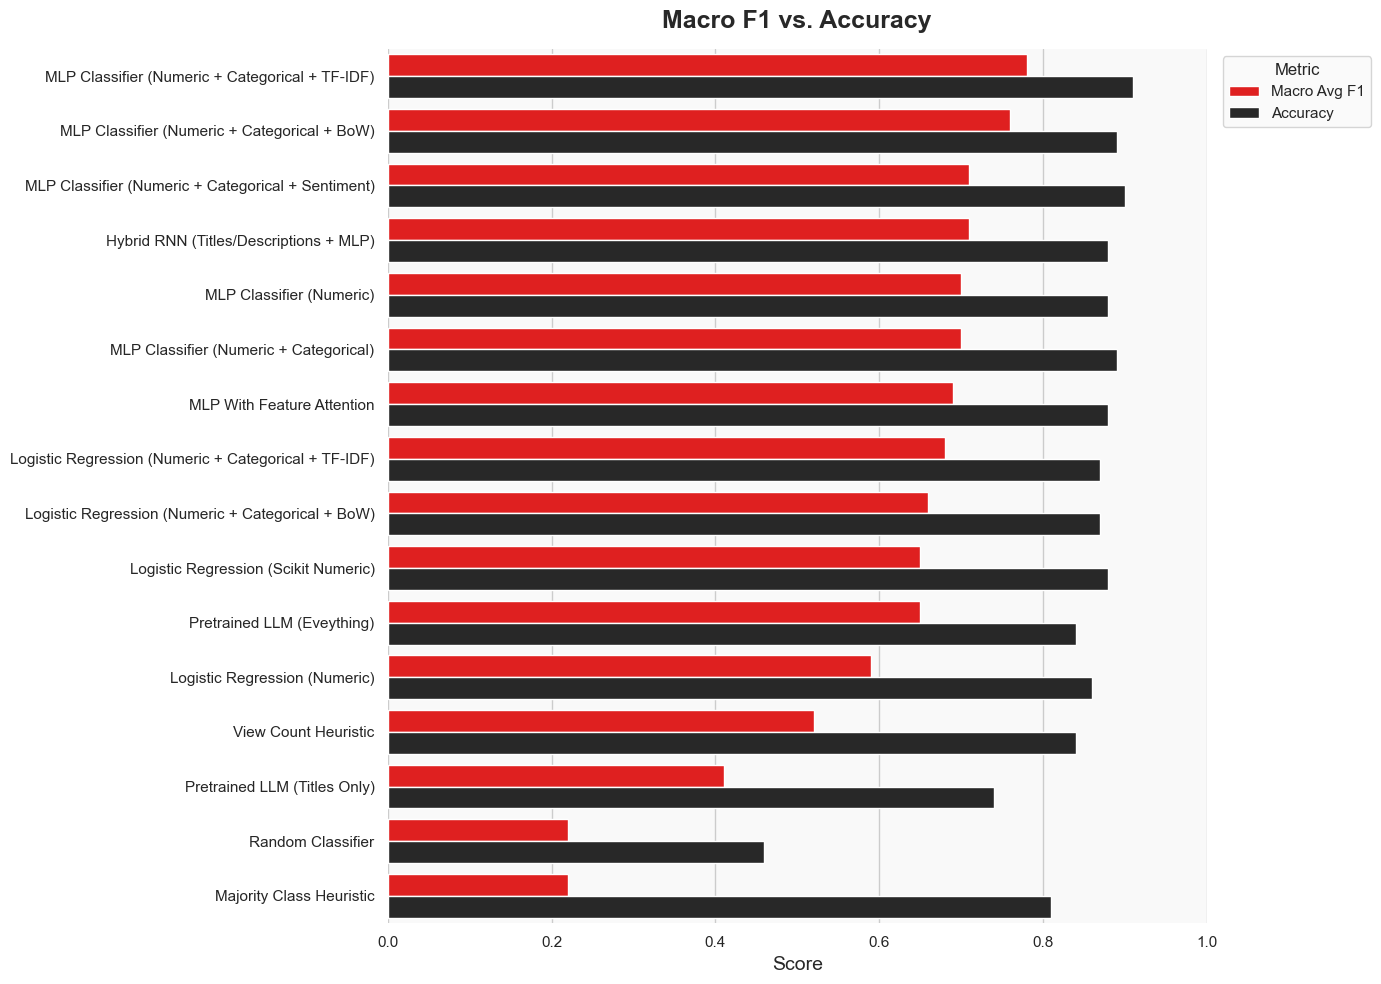

In [13]:
df_melted_f1_acc = df.melt(
    id_vars="Model Name", 
    value_vars=["Macro Avg F1", "Accuracy"], 
    var_name="Metric", 
    value_name="Score"
)

df_sorted_models = df.sort_values(by='Macro Avg F1', ascending=False)['Model Name']

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", rc={"axes.facecolor": yt_gray, "figure.facecolor": "white"})

palette = {
    "Macro Avg F1": yt_red, 
    "Accuracy": yt_black
}

ax2 = sns.barplot(
    x="Score", 
    y="Model Name", 
    hue="Metric", 
    data=df_melted_f1_acc, 
    palette=palette,
    order=df_sorted_models
)

plt.title("Macro F1 vs. Accuracy", fontsize=18, fontweight='bold', color=yt_black, pad=15)
plt.xlabel("Score", fontsize=14, color=yt_black)
plt.ylabel("", fontsize=14)
plt.xlim(0, 1.0)

plt.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Load just the best models in each category for comparison

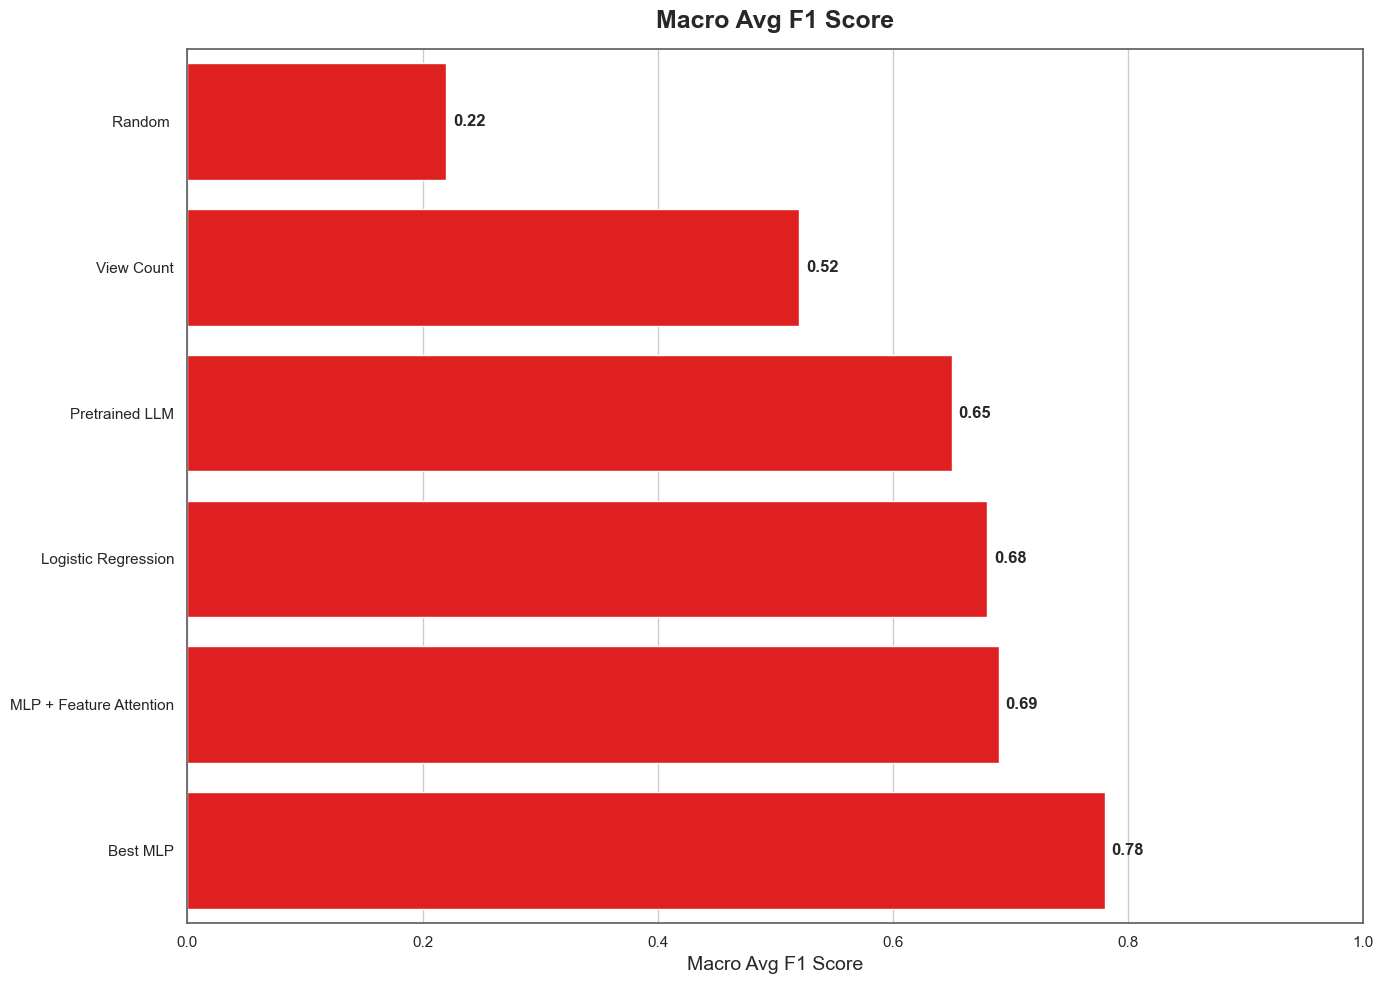

In [14]:
df = pd.read_csv('eval_best.csv')

df_sorted = df.sort_values(by="Macro Avg F1", ascending=True)

plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": yt_dark_gray})

ax1 = sns.barplot(x="Macro Avg F1", y="Model Name", data=df_sorted, color=yt_red)

plt.title("Macro Avg F1 Score", fontsize=18, fontweight='bold', color=yt_black, pad=15)
plt.xlabel("Macro Avg F1 Score", fontsize=14, color=yt_black)
plt.ylabel("", fontsize=14)
plt.xlim(0, 1)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.2f}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', 
                 xytext=(5, 0), textcoords='offset points',
                 fontsize=12, color=yt_black, fontweight='bold')
                 
plt.tight_layout()
plt.show()

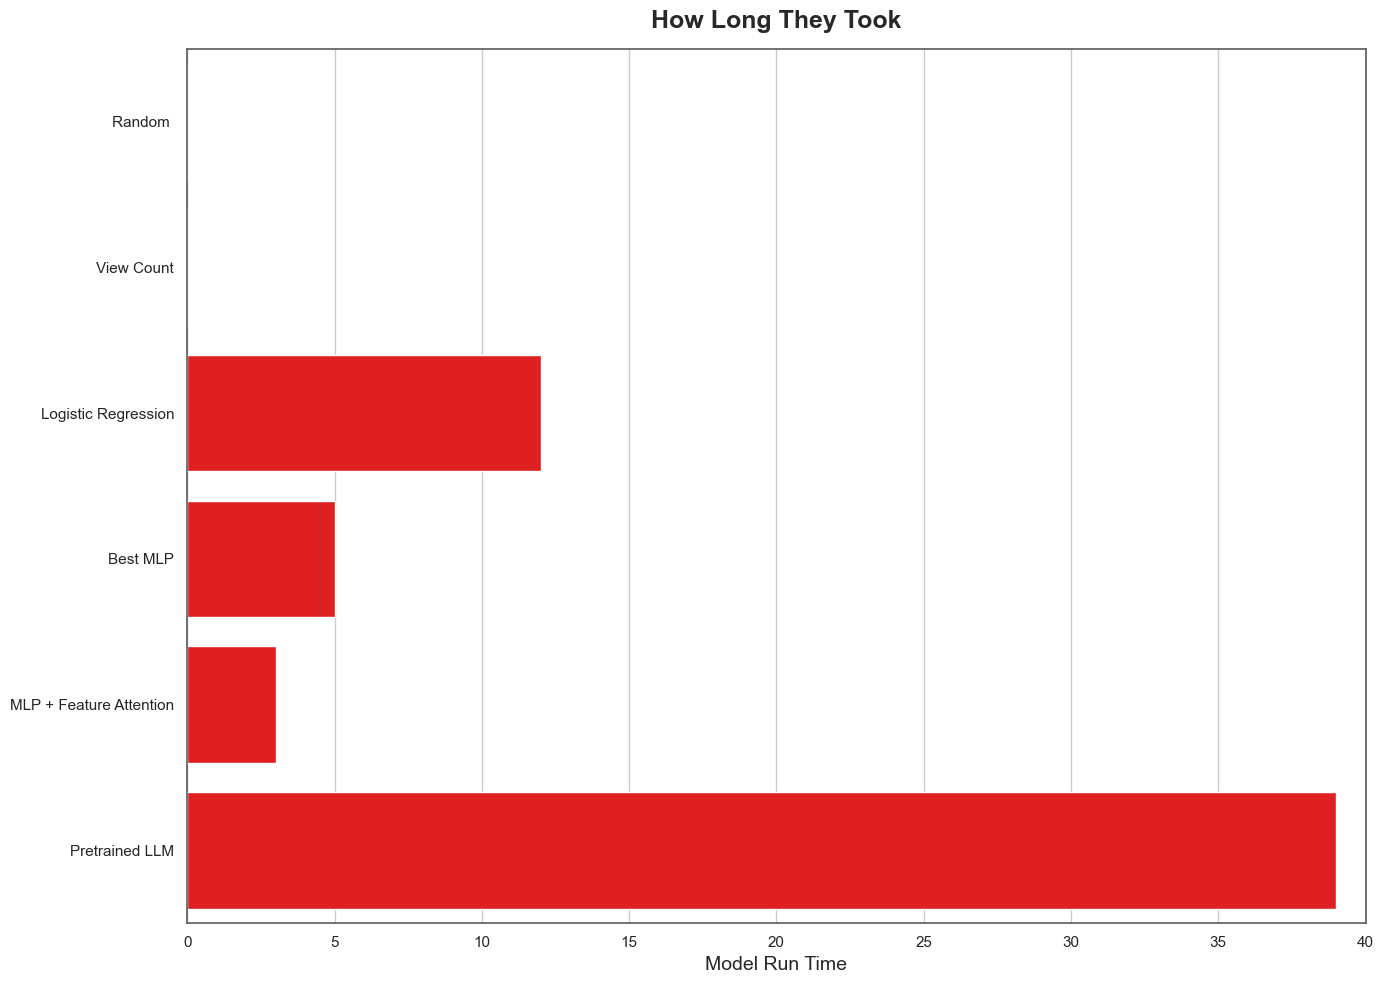

In [15]:
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": yt_dark_gray})

ax1 = sns.barplot(x="Run Time(m)", y="Model Name", data=df, color=yt_red)

plt.title("How Long They Took", fontsize=18, fontweight='bold', color=yt_black, pad=15)
plt.xlabel("Model Run Time", fontsize=14, color=yt_black)
plt.ylabel("", fontsize=14)
plt.xlim(0, 40)

plt.tight_layout()
plt.show()

#### Get the preformance and compare to how long each model took

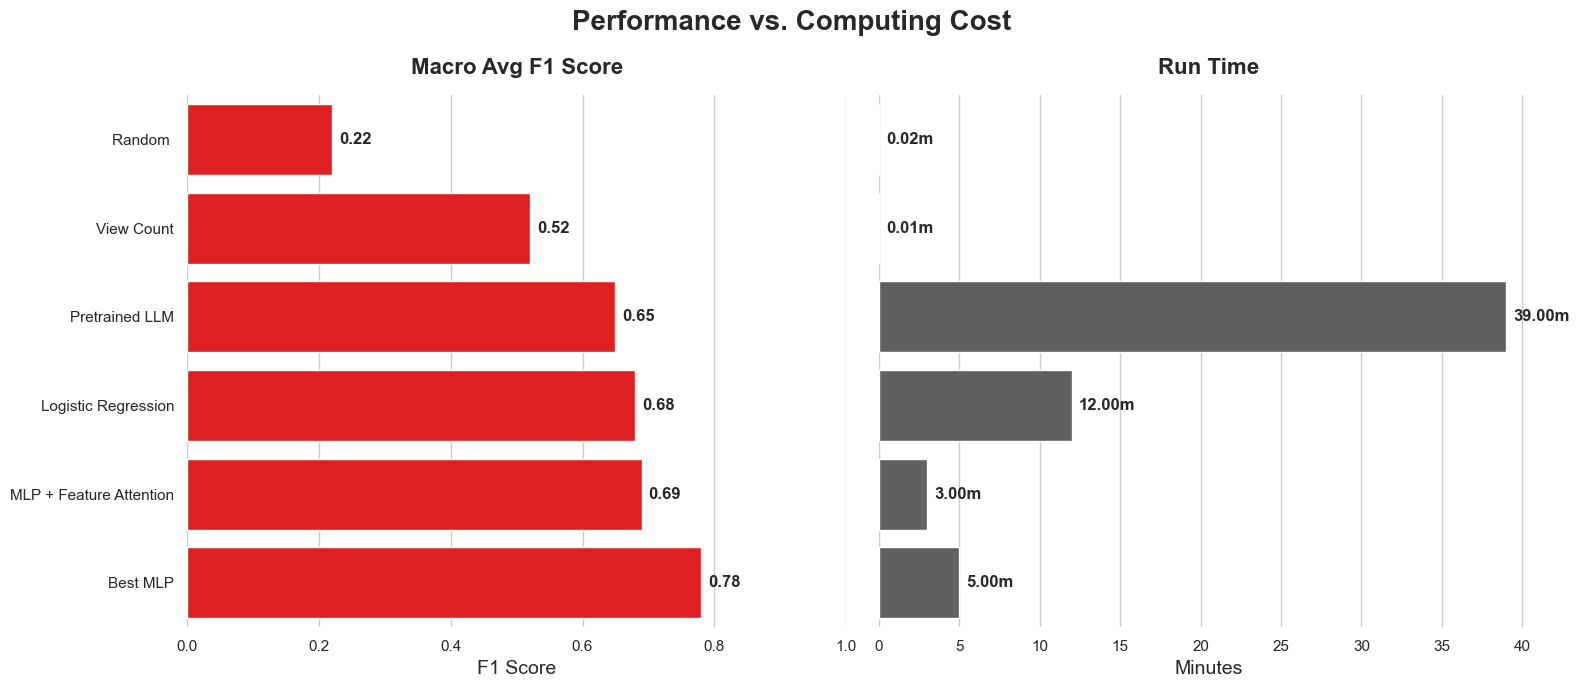

In [16]:
df = pd.read_csv('eval_best.csv')

yt_red = '#FF0000'
yt_black = '#282828'
yt_gray = '#F9F9F9'
yt_dark_gray = '#606060'

df_sorted = df.sort_values(by="Macro Avg F1", ascending=True)

sns.set_theme(style="whitegrid", rc={"axes.edgecolor": yt_dark_gray})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

sns.barplot(x="Macro Avg F1", y="Model Name", data=df_sorted, color=yt_red, ax=ax1)
ax1.set_title("Macro Avg F1 Score", fontsize=16, fontweight='bold', color=yt_black, pad=15)
ax1.set_xlabel("F1 Score", fontsize=14, color=yt_black)
ax1.set_ylabel("", fontsize=14)
ax1.set_xlim(0, 1.0)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.2f}', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=12, color=yt_black, fontweight='bold')

sns.barplot(x="Run Time(m)", y="Model Name", data=df_sorted, color=yt_dark_gray, ax=ax2)
ax2.set_title("Run Time", fontsize=16, fontweight='bold', color=yt_black, pad=15)
ax2.set_xlabel("Minutes", fontsize=14, color=yt_black)
ax2.set_ylabel("", fontsize=14)

for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.2f}m', 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=12, color=yt_black, fontweight='bold')

plt.suptitle("Performance vs. Computing Cost", fontsize=20, fontweight='bold', color=yt_black)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()